# 03 — How cheaply can the saturation rule select a mask?

Notebook 02 measured selection quality. Here we measure the work needed to obtain those masks. Paper uses the pinned submodule's C++ selector; saturation tiles and Top-$R$ are implemented in [selectors.cpp](selectors.cpp). Python only prepares inputs, calls the kernels, checks their results, and plots the measurements.

This is a **CPU-resident selection microbenchmark**, not an SSD or inference benchmark. The input importance vector is already available on the CPU. The output is a CPU mask, selected importance, and a cost diagnostic. The oracle is not timed.

In [31]:
from pathlib import Path
from time import perf_counter_ns
from IPython.display import Markdown, display
import json, os, platform, subprocess, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MODEL = Path("../01/latency_model.json")
TRACE = Path("../02/activation_traces.npz")
QUALITY = Path("../02/oracle_results_fixed_r.csv")
UPSTREAM = Path("../../../upstream/vlm-flash")
RESULTS = Path("selection_results.csv")
ENVIRONMENT = Path("environment.json")
RUN_BENCHMARK = True
MAX_TRACES_PER_SHAPE = 32
BUDGETS = np.arange(1, 10) / 10
WARMUP, REPEATS = 5, 31

## Keep quality fixed while measuring selection time.

For case $j=(v,R)$ and method $m$, time one native call:

$$t_{j,m,r}=t_{\mathrm{return}}-t_{\mathrm{call}},\qquad
\widehat t_{j,m}=\operatorname{median}_{r=1,\ldots,31}t_{j,m,r}.$$

All methods receive the same contiguous CPU float32 vector and requested $R$. Tiles and Top-$R$ select exactly $R$; Paper retains its reference underfill rule. We check the masks against Notebook 02 before timing and carry over its quality and fill diagnostics. A tied mask may differ only if its selected count, importance, and merged-run cost agree.

The timed Paper entry point is the **unchanged native kernel**, with CPU sorting explicitly selected. Its window sizes, costs, and stride are resolved by upstream code before timing, since they do not depend on $v$. Candidate scoring, sorting, overlap checks, mask allocation, and output construction remain timed. The public Python policy wrapper, importance extraction, compilation, disk reads, and GPU transfers are excluded. Thus this compares prepared native CPU calls, not the GPU-to-GPU online path. Python binding and timer overhead are included for all three methods.

In [32]:
if RUN_BENCHMARK:
    import torch
    from torch.utils.cpp_extension import load
    os.environ.setdefault("MAX_JOBS", "1")
    torch.set_num_threads(1)
    sys.path.insert(0, str((UPSTREAM / "src").resolve()))
    import vlmflash
    from vlmflash._native import native
    from vlmflash.policy import _window_sweep
    assert Path(vlmflash.__file__).resolve().is_relative_to(UPSTREAM.resolve())
    paper_native = native()
    assert paper_native is not None, "Build the reference native extension first."
    selectors = load("vlmflash_selection03", [str(Path("selectors.cpp").resolve())],
                     extra_cflags=["-O3", "-std=c++17"], verbose=False)

## Tiles need a selected set, not a complete ranking.

The rule is unchanged from Notebook 02. Put $B=\lceil s\rceil$, $k=\lfloor R/B\rfloor$, and $r=R\bmod B$. At offsets $0$ and $\lfloor B/2\rfloor$, select the $k$ full tiles with the largest importance, then the best disjoint length-$r$ interval. Choose between the two masks using the same merged-run $I/L$. If $R<B$, select the best contiguous $R$-run.

For $m$ disjoint tile candidates, only membership in the largest $k$ is needed. C++ `std::nth_element` replaces the full sort; ties prefer the earlier tile. This gives average $O(m)$ partial-selection work, rather than $O(m\log m)$ full sorting. Prefix sums, residual scanning, and mask construction remain $O(N)$. This is not a worst-case linear-time claim for `nth_element`, nor a guarantee of a speedup.

Paper's overlapping multiscale candidate set and greedy pass are left untouched. Its extra work and the quality it gains are the quantities being compared.

In [33]:
if RUN_BENCHMARK:
    model = json.loads(MODEL.read_text())
    s_kib, c1, delta, s99 = (model[k] for k in
        ("s_kib", "c1_ms_per_kib", "delta_ms_per_kib", "s99_kib"))
    table = vlmflash.LatencyTable({z: c1*z + delta*max(s_kib, z)
        for z in range(1, int(np.ceil(max(s_kib, s99))) + 2)})
    with np.load(TRACE, allow_pickle=False) as archive:
        manifest = json.loads(str(archive["manifest_json"].item()))
        traces = [{**t, "values": archive[t["array"]].astype(float)} for t in manifest["traces"]]
    if MAX_TRACES_PER_SHAPE:
        groups = [[t for t in traces if t["shape"] == shape] for shape in sorted({t["shape"] for t in traces})]
        traces = [g[i] for g in groups for i in np.linspace(
            0, len(g)-1, min(len(g), MAX_TRACES_PER_SHAPE), dtype=int)]
    traces.sort(key=lambda t: t["trace_id"])
    weight_bytes = {"float16": 2, "bfloat16": 2, "float32": 4}[manifest["model_dtype"]]
    quality = pd.read_csv(QUALITY)
    quality["fraction"] = quality.fraction.round(6)
    quality = quality.set_index(["trace_id", "fraction", "method"])
    geometry = {"896x128": (8,8), "896x896": (8,8), "896x4864": (8,8), "4864x896": (12,16)}

## Interleave the methods and keep the individual timings.

Each case has five warm-up rounds, followed by 31 timed rounds. A fixed random seed changes method order in each round. Inputs are reused; masks and scores are recomputed on every call. Both extensions use the same compiler and `-O3`; Torch uses one CPU thread. No forced GPU synchronization is needed because every timed kernel is CPU-only.

Per-case medians and 95th percentiles describe the observed calls, not confidence intervals. Speedups are paired within each case before aggregation. The saved samples and environment identify this run; timings on a shared host do not establish deployment performance. Set `RUN_BENCHMARK = True` to replace the CSV, or leave it false to read the report without compilation.

In [34]:
if RUN_BENCHMARK:
    rng, records = np.random.default_rng(0), []
    for i, trace in enumerate(traces, 1):
        v = trace["values"]
        v = (v / v.mean()).astype(np.float32) if v.any() else v.astype(np.float32)
        values, N = torch.from_numpy(v), len(v)
        w = weight_bytes * trace["d"] / 1024
        s, b1, b2 = s_kib/w, w*c1, w*(c1+delta)
        length = np.arange(N+1)
        T = b2*length + (b2-b1)*np.maximum(s-length, 0)
        T[0] = 0
        costs = torch.from_numpy(T)
        start, jump = geometry[trace["shape"]]
        params = vlmflash.ChunkParams(start_kb=start, step_kb=start, jump_cap_kb=jump, end_kb=s99+1)
        windows, stride = _window_sweep(N, w, table, params)
        sizes = torch.tensor([z for z, _ in windows], dtype=torch.int64)
        delays = torch.tensor([t for _, t in windows], dtype=torch.float64)
        for fraction in BUDGETS:
            R = max(1, int(fraction*N))
            functions = {
                "Paper greedy": lambda: paper_native.select_chunks(values, R, sizes, delays, stride, True),
                "Saturation tiles": lambda: selectors.tiles(values, R, costs, int(np.ceil(s))),
                "Top-R": lambda: selectors.top_r(values, R, costs),
            }
            checked = {}
            for name, fn in functions.items():
                mask = fn()[0].numpy().astype(bool)
                old = quality.loc[(trace["trace_id"], round(float(fraction),6), name)]
                expected = np.zeros(N, bool)
                for a, b in json.loads(old.intervals): expected[a:b] = True
                spans = np.flatnonzero(np.diff(np.r_[False, mask, False])).reshape(-1,2)
                I, L = v.astype(float)[mask].sum(), T[np.diff(spans, axis=1).ravel()].sum()
                assert mask.sum() == old.R_selected
                assert mask.sum() <= R if name == "Paper greedy" else mask.sum() == R
                np.testing.assert_allclose([I,L], [old.importance,old.latency], rtol=1e-10, atol=1e-12)
                checked[name] = (old, np.array_equal(mask, expected))
            samples = {name: [] for name in functions}
            names = list(functions)
            for repeat in range(WARMUP + REPEATS):
                for j in rng.permutation(len(names)):
                    name = names[j]
                    fn = functions[name]
                    begin = perf_counter_ns()
                    result = fn()
                    elapsed = (perf_counter_ns() - begin) / 1000
                    if repeat >= WARMUP: samples[name].append(elapsed)
            for name, times in samples.items():
                old, matches = checked[name]
                records.append(dict(trace_id=trace["trace_id"], shape=trace["shape"],
                    fraction=float(fraction), R_nominal=R, R_selected=int(old.R_selected), method=name,
                    median_us=np.median(times), p95_us=np.percentile(times,95),
                    gap_upper_pct=old.gap_upper_pct, fill_pct=old.fill_pct,
                    mask_matches_02=matches, samples_us=json.dumps(times)))
        pd.DataFrame(records).to_csv(RESULTS,index=False)
        if i % 16 == 0 or i == len(traces): print(f"{i}/{len(traces)} traces measured")

16/128 traces measured
32/128 traces measured
48/128 traces measured
64/128 traces measured
80/128 traces measured
96/128 traces measured
112/128 traces measured
128/128 traces measured


In [35]:
if RUN_BENCHMARK:
    cpu = next((s.split(":",1)[1].strip() for s in Path("/proc/cpuinfo").read_text().splitlines()
                if s.startswith("model name")), platform.machine())
    environment = dict(platform=platform.platform(), cpu=cpu, python=platform.python_version(),
        torch=torch.__version__, compiler=subprocess.check_output([os.environ.get("CXX","c++"),"--version"],text=True).splitlines()[0],
        flags="-O3; C++17", torch_threads=torch.get_num_threads(), cuda_sort=False,
        traces=len(traces), budgets=list(BUDGETS), warmup=WARMUP, repeats=REPEATS,
        source_commit="cc4f8c589716fbcaee186cc9f2b928193d25a65e", upstream_commit="9023679ebfd1900fa2912c4098f51bfb9efa7bb8")
    ENVIRONMENT.write_text(json.dumps(environment,indent=2))
frame = pd.read_csv(RESULTS) if RESULTS.is_file() else pd.DataFrame()
if ENVIRONMENT.is_file(): display(pd.Series(json.loads(ENVIRONMENT.read_text())))

platform           Linux-7.2.5-200.fc44.x86_64-x86_64-with-glibc2.43
cpu                       AMD Ryzen 7 8845HS w/ Radeon 780M Graphics
python                                                       3.13.11
torch                                                   2.11.0+cu130
compiler                c++ (GCC) 16.2.1 20260819 (Red Hat 16.2.1-2)
flags                                                     -O3; C++17
torch_threads                                                      1
cuda_sort                                                      False
traces                                                           128
budgets                [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
warmup                                                             5
repeats                                                           31
source_commit               cc4f8c589716fbcaee186cc9f2b928193d25a65e
upstream_commit             9023679ebfd1900fa2912c4098f51bfb9efa7bb8
dtype: object

## Compare selection time on the same cases.

$$S_j=\frac{\widehat t_{j,\mathrm{Paper}}}{\widehat t_{j,\mathrm{Tiles}}}.$$

A value above one favors tiles. This is selection speed, not flash-read speed. Paper's smaller realized mask is preserved and its fill percentage remains visible. Ratios of shape-level medians are not substituted for the median of the paired speedups.

method,Paper greedy,Saturation tiles,Top-R,Paper / Tiles
shape,,,,
4864x896,171.656,21.270,35.762,8.011
896x128,66.514,3.406,6.582,19.025
896x4864,187.901,6.928,7.820,27.212
896x896,129.653,6.031,6.938,21.939


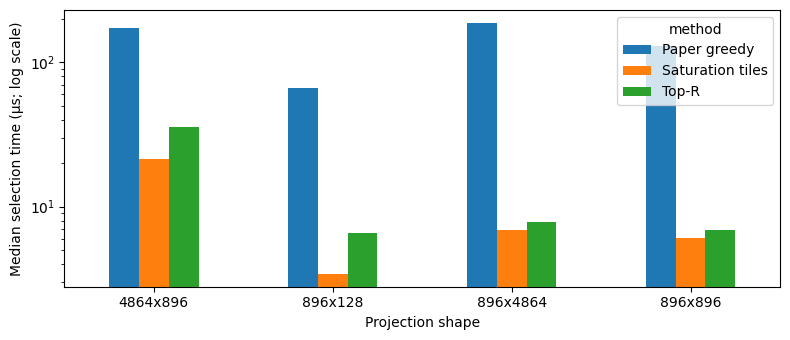

In [36]:
if not frame.empty:
    times = frame.pivot(index=["shape","trace_id","fraction"],columns="method",values="median_us")
    speedup = (times["Paper greedy"] / times["Saturation tiles"]).rename("Paper / Tiles")
    summary = frame.groupby(["shape","method"]).median_us.median().unstack()
    summary["Paper / Tiles"] = speedup.groupby("shape").median()
    display(summary.round(3))
    ax = summary.drop(columns="Paper / Tiles").plot.bar(figsize=(8,3.5),rot=0)
    ax.set(ylabel="Median selection time (µs; log scale)", xlabel="Projection shape", yscale="log")
    plt.tight_layout()
    plt.show()

## Pair speed and quality only where the budgets match.

The next summary uses the same exact-fill cases for all three methods. Underfilled Paper has no fixed-$R$ quality gap, and is not assigned zero. Each point is a pair of medians across cases, not an individual mask or a Pareto frontier. The full timing comparison above still includes underfill.

,cases,exact_fill,median_fill_pct
method,,,
Paper greedy,1152,480,99.93146
Saturation tiles,1152,1152,100.00000
Top-R,1152,1152,100.00000


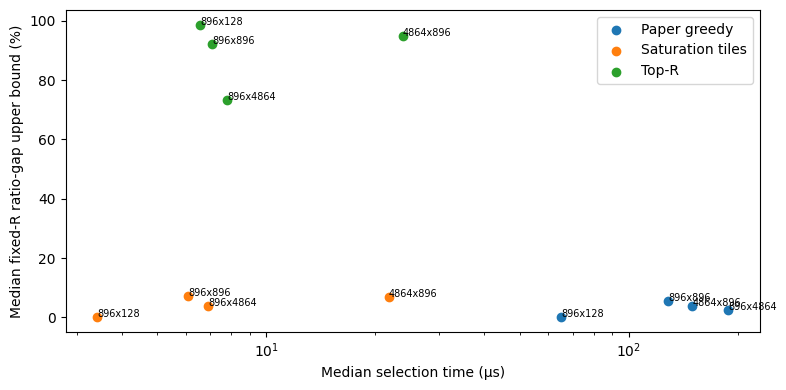

In [37]:
if not frame.empty:
    keys = ["trace_id","fraction"]
    eligible = frame[(frame.method == "Paper greedy") & frame.gap_upper_pct.notna()][keys]
    matched = frame.merge(eligible,on=keys,validate="many_to_one")
    display(frame.groupby("method").agg(cases=("median_us","size"),
        exact_fill=("gap_upper_pct","count"), median_fill_pct=("fill_pct","median")))
    if not matched.empty:
        points = matched.groupby(["shape","method"])[["median_us","gap_upper_pct"]].median().reset_index()
        plt.figure(figsize=(8,4))
        for method, data in points.groupby("method"):
            plt.scatter(data.median_us,data.gap_upper_pct,label=method)
            for p in data.itertuples(): plt.annotate(p.shape,(p.median_us,p.gap_upper_pct),fontsize=7)
        plt.xscale("log")
        plt.xlabel("Median selection time (µs)")
        plt.ylabel("Median fixed-R ratio-gap upper bound (%)")
        plt.legend()
        plt.tight_layout()
        plt.show()

In [38]:
if not frame.empty:
    low, high = speedup.quantile([.05,.95])
    display(Markdown(
        f"Across **{len(times):,}** saved cases, the median paired Paper/Tiles selection-time ratio is "
        f"**{speedup.median():.2f}×** (5th–95th case percentiles: **{low:.2f}–{high:.2f}×**). "
        f"**{int(frame.mask_matches_02.sum()):,}/{len(frame):,}** masks match Notebook 02 exactly; "
        "all evaluated masks passed the selected-count, importance, and merged-cost checks."
    ))

Across **1,152** saved cases, the median paired Paper/Tiles selection-time ratio is **20.34×** (5th–95th case percentiles: **7.07–30.26×**). **3,456/3,456** masks match Notebook 02 exactly; all evaluated masks passed the selected-count, importance, and merged-cost checks.

## Add the modeled read cost, without another benchmark.

Notebook 02 already records the fitted read cost of each mask. Join those rows to the measured selection times and add in milliseconds:

$$\widehat C_{j,m}=\frac{\widehat t_{j,m}}{1000}+\widehat L(M_{j,m}).$$

Tiles have a lower composed cost precisely when their selection saving exceeds any additional modeled read cost:

$$\frac{\widehat t_{j,P}-\widehat t_{j,T}}{1000}>\widehat L(M_{j,T})-\widehat L(M_{j,P}).$$

This reuses `selection_results.csv` and `../02/oracle_results_fixed_r.csv`; no selector or SSD measurement is repeated. The recorded CPU timings and Notebook 01's SSD model form a **composed estimate**, not a same-machine wall-time measurement. Compute, transfers, scheduling, and overlap are not measured by this sum.

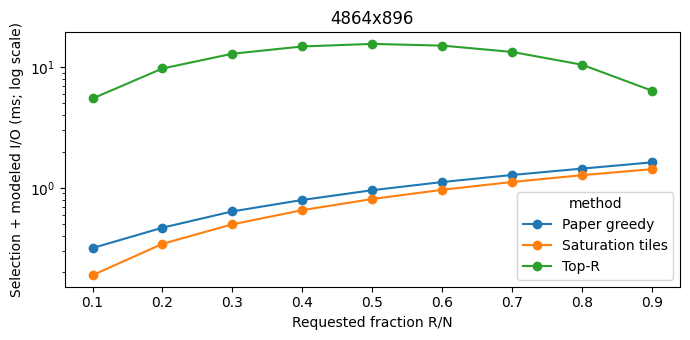

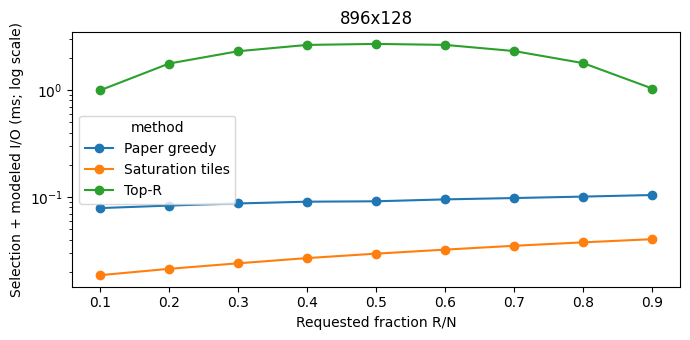

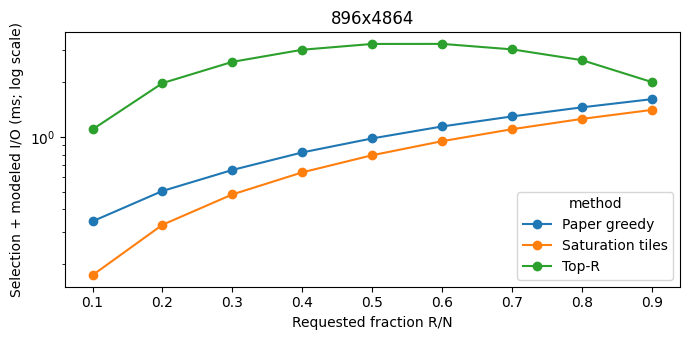

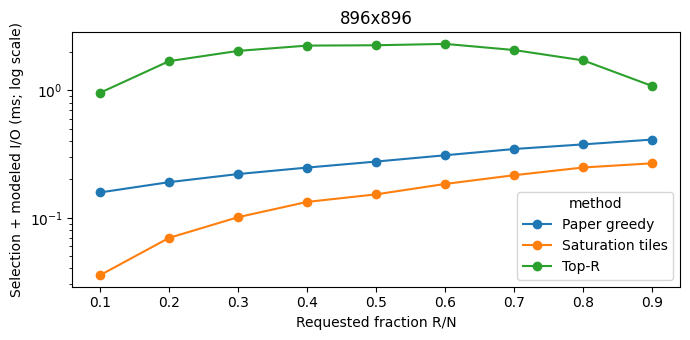

In [39]:
if not frame.empty:
    keys = ["shape", "trace_id", "fraction", "R_nominal", "R_selected", "method"]
    io = pd.read_csv(QUALITY, usecols=keys + ["latency"]).rename(columns={"latency": "modeled_io_ms"})
    io["fraction"] = io.fraction.round(6)
    online = frame.assign(fraction=frame.fraction.round(6)).merge(io, on=keys, how="left", validate="one_to_one")
    assert online.modeled_io_ms.notna().all(), "02 must contain the same measured cases and selected counts."
    online["selection_ms"] = online.median_us / 1000
    online["combined_ms"] = online.selection_ms + online.modeled_io_ms
    for shape, data in online.groupby("shape"):
        curves = data.groupby(["fraction", "method"]).combined_ms.median().unstack()
        ax = curves.plot(marker="o", figsize=(7, 3.5), logy=True)
        ax.set(title=shape, xlabel="Requested fraction R/N", ylabel="Selection + modeled I/O (ms; log scale)")
        plt.tight_layout()
        plt.show()

The curves summarize all saved cases at each requested budget, including Paper underfill. They are not equal-importance comparisons. The table below instead uses only cases where Paper fills the requested $R$, paired across all methods. Equal counts match row volume, not necessarily importance or compute time. Each column is a median across those same cases; the combined column is the median of per-case sums, not the sum of the other two medians.

In [40]:
if not frame.empty:
    case = ["shape", "trace_id", "fraction", "R_nominal"]
    paper_rows = online[online.method == "Paper greedy"]
    filled = paper_rows[paper_rows.R_selected == paper_rows.R_nominal][case]
    exact = online.merge(filled, on=case, validate="many_to_one")
    if not exact.empty:
        display(exact.groupby("method")[["selection_ms", "modeled_io_ms", "combined_ms"]].median().round(4))
        paired = exact.pivot(index=case, columns="method", values="combined_ms")
        ratio = paired["Paper greedy"] / paired["Saturation tiles"]
        saving = paired["Paper greedy"] - paired["Saturation tiles"]
        display(Markdown(
            f"On **{len(paired):,}/{len(paper_rows):,}** exact-fill cases, tiles have a lower composed cost in "
            f"**{int((saving > 0).sum()):,}/{len(paired):,}** pairs. The median paired Paper/Tiles ratio is "
            f"**{ratio.median():.2f}×**, with a median paired saving of **{saving.median():.3f} ms**. "
            "These are selection-plus-modeled-read estimates, not observed wall-time gains or equal-quality gains."))
    else:
        display(Markdown("No Paper exact-fill cases are available for a paired cost comparison."))
    higher = paper_rows[paper_rows.fraction > 0.1]
    if not higher.empty:
        display(Markdown(
            f"Above the 10% requested budget, Paper's median fill is **{higher.fill_pct.median():.2f}%**; "
            f"**{100 * higher.fill_pct.ge(95).mean():.2f}%** of cases fill at least 95%. "
            "Near-full cases remain outside the exact-fill table; their trade-offs stay in the curves."))

,selection_ms,modeled_io_ms,combined_ms
method,,,
Paper greedy,0.1655,0.3345,0.5053
Saturation tiles,0.0067,0.3226,0.3439
Top-R,0.0078,2.6750,2.6815


On **480/1,152** exact-fill cases, tiles have a lower composed cost in **480/480** pairs. The median paired Paper/Tiles ratio is **1.41×**, with a median paired saving of **0.166 ms**. These are selection-plus-modeled-read estimates, not observed wall-time gains or equal-quality gains.

Above the 10% requested budget, Paper's median fill is **99.93%**; **96.88%** of cases fill at least 95%. Near-full cases remain outside the exact-fill table; their trade-offs stay in the curves.

The measurement concerns the recorded CPU, compiler, library version, and prepared-native interface. A lower selection time is not an end-to-end speedup. It does not validate the fitted SSD cost, and it does not include GPU-resident activation transfer or the reference selector's optional CUDA sort. A GPU deployment needs a separately defined timing boundary.

Sources: [Notebook 02](../02/02_global_oracle.ipynb), [reference policy](../../../upstream/vlm-flash/src/vlmflash/policy.py), [reference native kernel](../../../upstream/vlm-flash/src/vlmflash/csrc/native.cc), and the [C++ extension interface](https://docs.pytorch.org/docs/stable/cpp_extension.html). `std::nth_element` has average linear complexity for the ordinary overload; it does not impose an order on the selected group.